In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
#epochs._data = Scaler(scalings='mean').fit_transform(epochs._data)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
4195,1,0,0
4196,1,0,0
4197,1,0,0
4198,1,0,0


In [5]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_1006/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(4200, 8, 26)

In [6]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.cov import ledoit_wolf_shrinkage, oas, mode_scatter
import warnings

from hoda.hoda import f_oneway, mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = HODA(
       max_iter=64,
        tol=1e-16,
        init ='mlsvd',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
)

hoda

HODA(init='mlsvd', max_iter=64, tol=1e-16, verbose=True)

In [7]:
import matplotlib.pyplot as plt
import math
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import log_loss
from hoda.classification import Vectorize
import math

mses=[]
Fs = []
lls = []
bics = []
aics = []
aiccs = []


n_samples = X.shape[0]
for r in range(1,max(X.shape[1:])+1):
    hoda.set_params(rank=r)
    hoda.fit(X,y)
    mses.append(float(tl.metrics.regression.MSE(tl.tensor(X),hoda.inv_transform(hoda.transform(X)))))

    Xt = hoda.transform(X)
    F = float(f_multiway(Xt, y, method='rt'))
    Fs.append(F)
    ll = np.log(F)*n_samples
    lls.append(ll)


    #k = hoda.n_params_
    k = math.prod(Xt.shape[1:])
    n = Xt.shape[0]
    bics.append(k*np.log(n)-2*ll)
    aic = 2*k-2*ll
    aics.append(aic)
    aiccs.append(aic+ (2*k**2+2*k)/(n-k-1))


Fitting discriminative tensor model of rank (1, 1)...


  0%|          | 0/64 [00:00<?, ?it/s]

Fitting discriminative tensor model of rank (2, 2)...


  0%|          | 0/64 [00:00<?, ?it/s]

Fitting discriminative tensor model of rank (3, 3)...


...

  0%|          | 0/64 [00:00<?, ?it/s]

Fitting discriminative tensor model of rank (8, 25)...


  0%|          | 0/64 [00:00<?, ?it/s]

Fitting discriminative tensor model of rank (8, 26)...


  0%|          | 0/64 [00:00<?, ?it/s]

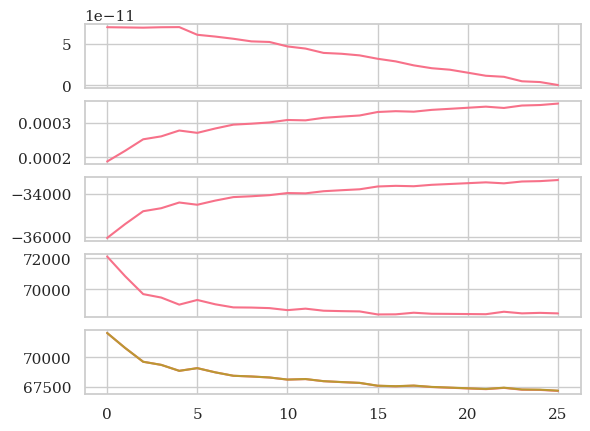

In [8]:
fig, axs = plt.subplots(5,1)
axs[0].plot(mses)
axs[1].plot(Fs)
axs[2].plot(lls)
axs[3].plot(bics)
axs[4].plot(aics)
axs[4].plot(aiccs)